In [1]:
import pandas as pd

df = pd.read_csv("agriculture_yield.csv")

print(df.shape)
print(df.columns)
print(df.head(10))

(1500, 8)
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8.3      5.8 

Number of Rows = 1500
Number of Columns = 8

Columns:

rainfall_mm
temperature_c
fertilizer_kg
irrigation_hours
soil_ph
crop_type
soil_type
yield_ton_per_hectare

In [2]:
print(df.dtypes)
print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


Missing Values:

All columns contain 0 missing values.

Conclusion: No missing values are present in the dataset.

In [3]:
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Feature with Highest Mean:

rainfall_mm
Mean = 754.05

Feature with Highest Standard Deviation:

rainfall_mm
Std = 255.10

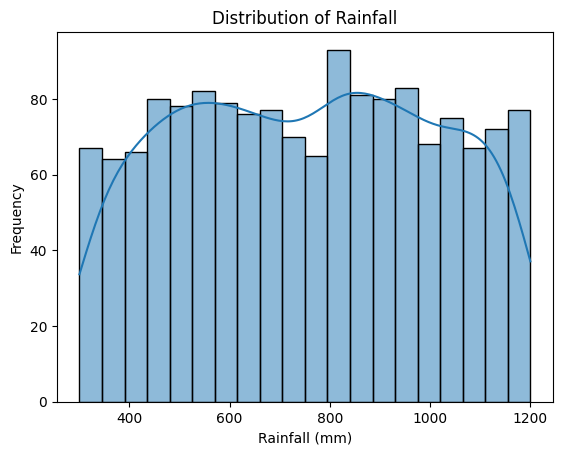

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(
    data=df,
    x='rainfall_mm',
    bins=20,
    kde=True
)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

Observations (Rainfall)
1) Rainfall values are distributed over a wide range.
2) Most observations are concentrated around the middle rainfall values.
3) No significant extreme outliers are visible.

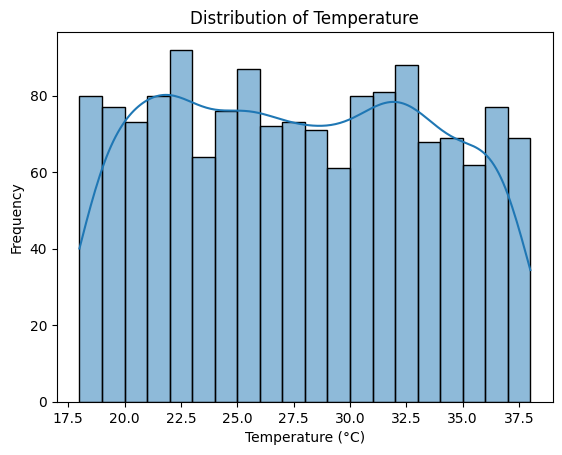

In [5]:
sns.histplot(
    data=df,
    x='temperature_c',
    bins=20,
    kde=True
)
plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

Observations (Temperature)
1) Temperature values appear fairly evenly distributed.
2) The distribution is approximately symmetric.
3) Most values are concentrated around the average temperature range.

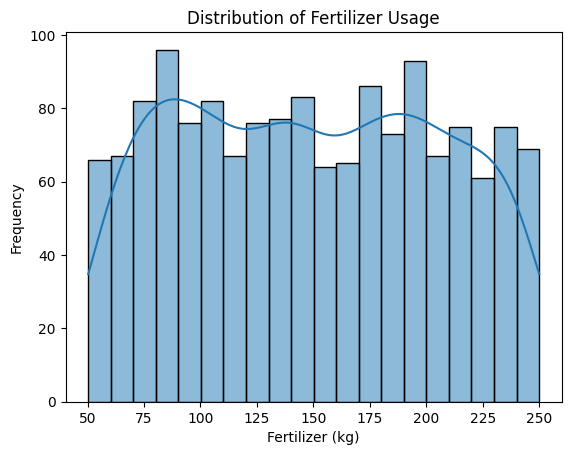

In [6]:
sns.histplot(
    data=df,
    x='fertilizer_kg',
    bins=20,
    kde=True
)
plt.title("Distribution of Fertilizer Usage")
plt.xlabel("Fertilizer (kg)")
plt.ylabel("Frequency")
plt.show()

Observations (Fertilizer)
1) Fertilizer usage covers a broad range of values.
2) The distribution does not show strong skewness.
3) No major outliers are observed.

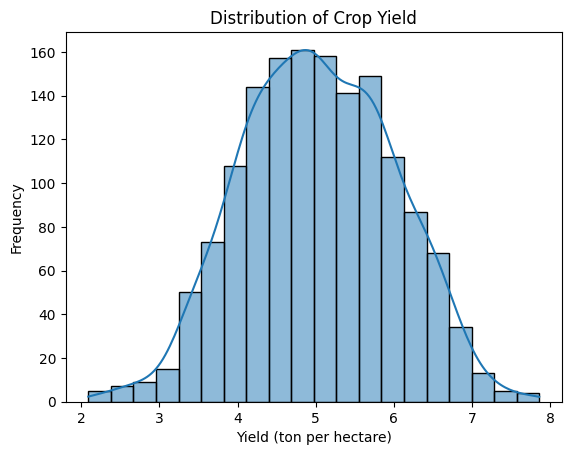

In [7]:
sns.histplot(
    data=df,
    x='yield_ton_per_hectare',
    bins=20,
    kde=True
)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (ton per hectare)")
plt.ylabel("Frequency")
plt.show()

Observations (Yield)
1) The yield distribution is approximately bell-shaped.
2) Most crop yields are concentrated around the central values.
3) Very few extreme high or low yield values are present.

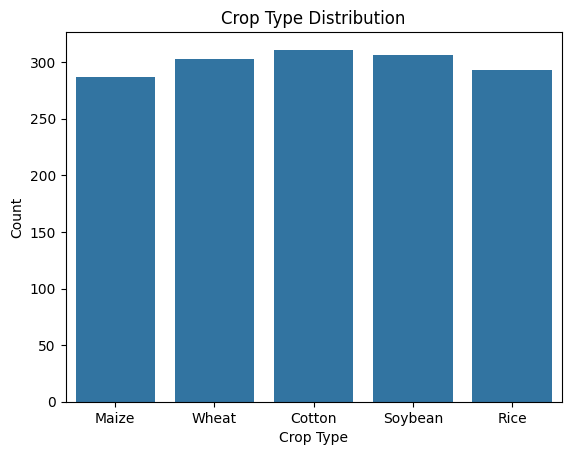

In [8]:
sns.countplot(data=df, x='crop_type')
plt.title("Crop Type Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()

Cotton     311

Soybean    306

Wheat      303

Rice       293

Maize      287

Most Frequent Crop:
Cotton

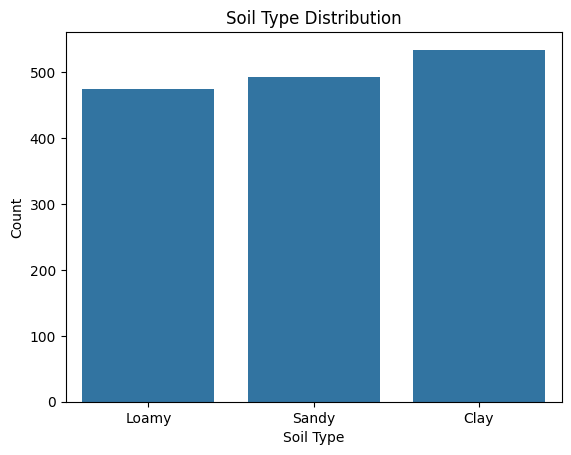

In [9]:
sns.countplot(data=df, x='soil_type')
plt.title("Soil Type Distribution")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.show()

Clay     534

Sandy    492

Loamy    474

Most Common Soil Type:
Clay

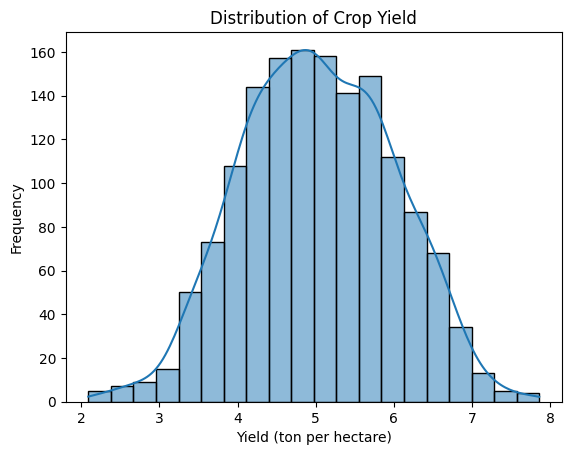

In [10]:
sns.histplot(
    data=df,
    x='yield_ton_per_hectare',
    bins=20,
    kde=True
)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (ton per hectare)")
plt.ylabel("Frequency")
plt.show()

Q1 Yes, the distribution appears to be approximately normal because most values are concentrated around the center and gradually decrease towards both ends, forming a bell-shaped pattern.
Q2 No significant outliers are visible in the histogram. Most yield values fall within a reasonable range and there are no isolated extreme values.

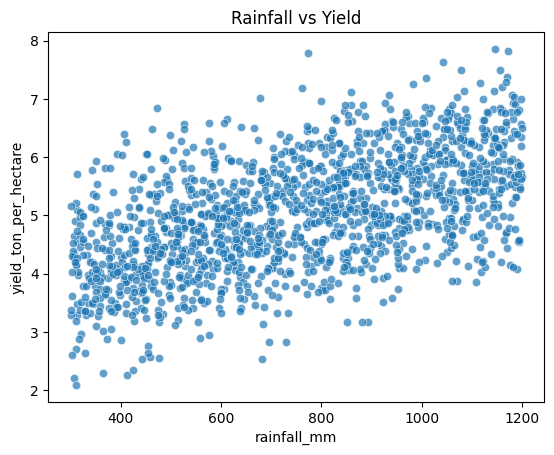

In [11]:
plt.title("Rainfall vs Yield")
sns.scatterplot(
    data=df,
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    alpha=0.7
)
plt.show()

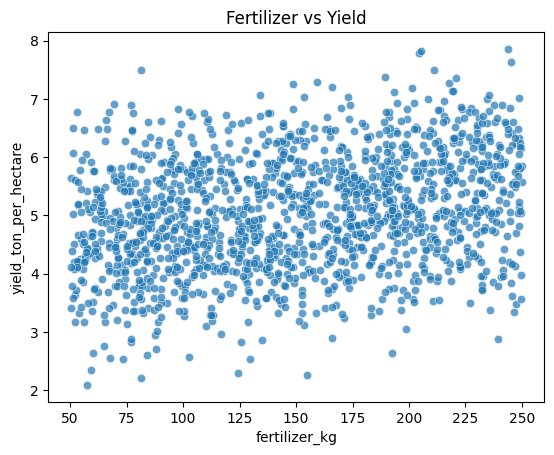

In [14]:
plt.title("Fertilizer vs Yield")

sns.scatterplot(
    data=df,
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    alpha=0.7
)

plt.show()

Rainfall appears to have a stronger relationship with crop yield than fertilizer usage.

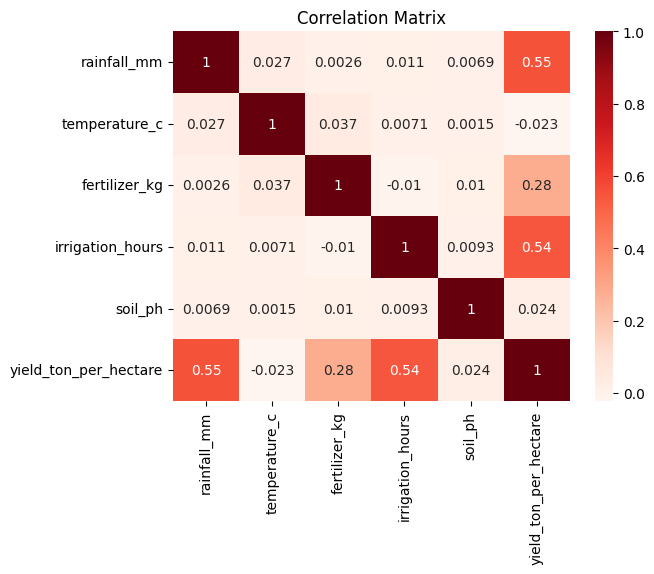

In [16]:
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap='Reds',
    annot=True
)
plt.title("Correlation Matrix")
plt.show()

Top 3 Features Correlated with Yield:

Feature     	  Correlation

rainfall_mm	        0.554

irrigation_hours	0.543

fertilizer_kg	    0.278

In [17]:
print(df.groupby('crop_type')
      ['yield_ton_per_hectare']
      .mean())

print(df.groupby('soil_type')
      ['yield_ton_per_hectare']
      .mean())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy

In [18]:
df_encoded = pd.get_dummies(
    df,
    columns=['crop_type','soil_type'],
    drop_first=True
)
print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat  soil_type_Loamy  soil_type_Sandy  
0            

In [19]:
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)
y = df_encoded['yield_ton_per_hectare']

Target Variable:
yield_ton_per_hectare

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1200, 11)
(300, 11)
(1200,)
(300,)


In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept:", model.intercept_)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coefficients.sort_values(
    by='Coefficient',
    ascending=False
))

Intercept: 1.587132027736121
              Feature  Coefficient
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
5     crop_type_Maize     0.238931
3    irrigation_hours     0.198327
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
10    soil_type_Sandy    -0.490933


Intercept:
1.5871

Feature with Highest Positive Coefficient:
crop_type_Rice

Coefficient ≈ 0.864